In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch, Rectangle
from matplotlib.lines import Line2D
from pathlib import Path

outdir = Path(".")
# Copy the figure-building code from the notebook if you want to regenerate elsewhere.
# This script is intentionally compact: it creates two files,
#   thesis_preprocessing_workflow.png
#   thesis_preprocessing_panels.png

def smooth(x, w=15):
    w = max(1, int(w))
    k = np.ones(w) / w
    return np.convolve(x, k, mode="same")

def draw_wave(ax, x0, y0, w, h, kind="audio", seed=0):
    rng = np.random.default_rng(seed)
    xs = np.linspace(x0 + 0.03*w, x0 + 0.97*w, 250)
    t = np.linspace(0, 1, 250)
    if kind == "audio":
        y = (0.45*np.sin(2*np.pi*7*t) + 0.18*np.sin(2*np.pi*19*t) +
             0.10*rng.normal(size=t.size))
        y = smooth(y, 3)
    elif kind == "env":
        y = 0.25*np.sin(2*np.pi*2.5*t) + 0.55*np.maximum(0, np.sin(2*np.pi*1.4*t-0.6))
        y = smooth(y, 9)
    elif kind == "eeg":
        y = 0.18*np.sin(2*np.pi*11*t) + 0.1*np.sin(2*np.pi*4*t+0.3) + 0.08*rng.normal(size=t.size)
        y += 0.8*np.exp(-((t-0.23)/0.02)**2) - 0.6*np.exp(-((t-0.73)/0.025)**2)
        y = smooth(y, 2)
    elif kind == "eeg_clean":
        y = 0.18*np.sin(2*np.pi*11*t) + 0.1*np.sin(2*np.pi*4*t+0.3) + 0.05*rng.normal(size=t.size)
        y = smooth(y, 4)
    elif kind == "trf":
        y = (0.6*np.exp(-((t-0.15)/0.04)**2) 
             - 0.45*np.exp(-((t-0.33)/0.05)**2)
             + 0.35*np.exp(-((t-0.58)/0.07)**2))
        y = smooth(y, 3)
    ys = y0 + h/2 + 0.35*h*y/np.max(np.abs(y))
    ax.plot(xs, ys, lw=1.7)

def box(ax, x, y, w, h, title, subtitle=None, fontsize=11):
    patch = FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.01,rounding_size=0.02",
                           linewidth=1.4, facecolor="white", edgecolor="black")
    ax.add_patch(patch)
    ax.text(x + 0.02*w, y + h - 0.18*h, title, fontsize=fontsize, fontweight="bold", va="top")
    if subtitle:
        ax.text(x + 0.02*w, y + 0.12*h, subtitle, fontsize=9, va="bottom")
    return patch

def arrow(ax, xy1, xy2):
    arr = FancyArrowPatch(xy1, xy2, arrowstyle='-|>', mutation_scale=12, linewidth=1.4, color='black')
    ax.add_patch(arr)

# Figure 1
fig, ax = plt.subplots(figsize=(16, 9))
ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.axis("off")
ax.text(0.03, 0.96, "Conceptual preprocessing workflow for EEG-speech TRF analysis", 
        fontsize=18, fontweight="bold", va="top")
ax.text(0.03, 0.925, "A figure suggestion for a thesis methods section: no real data, only the in-principle signal path.",
        fontsize=11, va="top")
ax.text(0.03, 0.82, "Speech branch", fontsize=13, fontweight="bold")
box(ax, 0.04, 0.63, 0.16, 0.15, "Continuous speech", "Raw audio waveform")
draw_wave(ax, 0.04, 0.63, 0.16, 0.15, "audio", seed=1)
box(ax, 0.26, 0.63, 0.18, 0.15, "Envelope extraction", "Gammatone / filterbank -> envelope")
draw_wave(ax, 0.26, 0.63, 0.18, 0.15, "env", seed=2)
box(ax, 0.50, 0.63, 0.18, 0.15, "Resample & align", "Match EEG sampling and trial timing")
for i in range(12):
    x = 0.53 + i*0.011
    ax.add_line(Line2D([x, x], [0.655, 0.73], lw=1))
ax.plot([0.52, 0.66], [0.69, 0.69], lw=1.2)
box(ax, 0.74, 0.63, 0.20, 0.15, "Stimulus predictor", "Envelope or lagged design matrix")
for i in range(8):
    for j in range(4):
        ax.add_patch(Rectangle((0.77 + i*0.018, 0.655 + j*0.018), 0.014, 0.014, fill=False, lw=0.8))
arrow(ax, (0.20, 0.705), (0.26, 0.705))
arrow(ax, (0.44, 0.705), (0.50, 0.705))
arrow(ax, (0.68, 0.705), (0.74, 0.705))
ax.text(0.03, 0.46, "EEG branch", fontsize=13, fontweight="bold")
box(ax, 0.04, 0.27, 0.16, 0.15, "EEG + EOG", "Scalp channels, mastoids, ocular channels")
draw_wave(ax, 0.04, 0.27, 0.16, 0.15, "eeg", seed=3)
box(ax, 0.26, 0.27, 0.18, 0.15, "Preprocessing", "Reference, filter, bad channels, ICA")
draw_wave(ax, 0.26, 0.27, 0.18, 0.15, "eeg_clean", seed=4)
box(ax, 0.50, 0.27, 0.18, 0.15, "Epoch / align", "Synchronize with stimulus segments")
for i in range(3):
    ax.add_patch(Rectangle((0.54 + i*0.035, 0.31), 0.025, 0.06, fill=False, lw=1))
box(ax, 0.74, 0.27, 0.20, 0.15, "Neural response matrix", "Channels x time (optionally lagged)")
for i in range(7):
    for j in range(3):
        ax.add_patch(Rectangle((0.77 + i*0.019, 0.305 + j*0.022), 0.015, 0.017, fill=False, lw=0.8))
arrow(ax, (0.20, 0.345), (0.26, 0.345))
arrow(ax, (0.44, 0.345), (0.50, 0.345))
arrow(ax, (0.68, 0.345), (0.74, 0.345))
box(ax, 0.28, 0.04, 0.18, 0.13, "TRF estimation", "Forward: stimulus -> EEG\nBackward: EEG -> stimulus")
draw_wave(ax, 0.30, 0.055, 0.12, 0.05, "trf", seed=5)
box(ax, 0.54, 0.04, 0.18, 0.13, "Cross-validation", "Train / validate / test; selective stopping")
for i in range(3):
    ax.add_patch(Rectangle((0.57 + i*0.043, 0.08), 0.03, 0.03, fill=False, lw=1))
box(ax, 0.78, 0.04, 0.16, 0.13, "Outputs", "TRF weights, topographies,\nprediction correlation / decoding accuracy")
arrow(ax, (0.84, 0.63), (0.37, 0.17))
arrow(ax, (0.84, 0.27), (0.37, 0.17))
arrow(ax, (0.46, 0.105), (0.54, 0.105))
arrow(ax, (0.72, 0.105), (0.78, 0.105))
fig.savefig(outdir / "thesis_preprocessing_workflow.png", dpi=200, bbox_inches="tight")
plt.close(fig)

# Figure 2
fig, axs = plt.subplots(2, 3, figsize=(14, 7), constrained_layout=True)
t = np.linspace(0, 4, 1200)
rng = np.random.default_rng(7)
audio = 0.5*np.sin(2*np.pi*3*t) + 0.3*np.sin(2*np.pi*8*t+0.4) + 0.08*rng.normal(size=t.size)
env = smooth(np.abs(audio), 60)
t_ds = np.linspace(0, 4, 80)
env_ds = np.interp(t_ds, t, env)
eeg = 0.2*np.sin(2*np.pi*10*t) + 0.1*np.sin(2*np.pi*5*t+0.7) + 0.05*rng.normal(size=t.size)
blink = 1.1*np.exp(-((t-1.2)/0.08)**2) - 0.7*np.exp(-((t-2.7)/0.09)**2)
eeg_raw = eeg + blink
eeg_clean = smooth(eeg, 5)
lags = np.linspace(-0.1, 1.0, 200)
trf = 0.6*np.exp(-((lags-0.12)/0.05)**2) - 0.45*np.exp(-((lags-0.28)/0.07)**2) + 0.28*np.exp(-((lags-0.52)/0.09)**2)

axs[0,0].plot(t, audio, lw=1.2); axs[0,0].set_title("Speech waveform")
axs[0,1].plot(t, env, lw=1.2); axs[0,1].set_title("Extracted envelope")
axs[0,2].plot(t, env, lw=0.9); axs[0,2].plot(t_ds, env_ds, "o", ms=3); axs[0,2].set_title("Resample to EEG rate")
axs[1,0].plot(t, eeg_raw, lw=1.0); axs[1,0].set_title("Raw EEG with ocular artifacts")
axs[1,1].plot(t, eeg_clean, lw=1.0); axs[1,1].set_title("Preprocessed EEG")
axs[1,2].plot(lags*1000, trf, lw=1.4); axs[1,2].axvline(0, lw=0.8); axs[1,2].set_title("Illustrative TRF")

for ax in axs.flat:
    ax.set_xlabel("Time")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
axs[1,2].set_xlabel("Lag (ms)")
fig.savefig(outdir / "thesis_preprocessing_panels.png", dpi=200, bbox_inches="tight")
plt.close(fig)

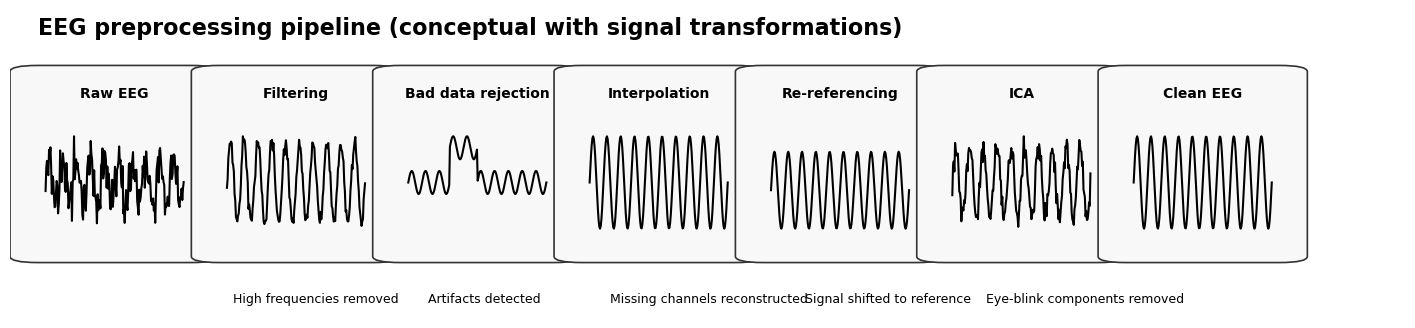

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

# ------------------------------------------------
# Helper functions
# ------------------------------------------------
def box(ax, x, y, w, h, title):
    patch = FancyBboxPatch(
        (x, y), w, h,
        boxstyle="round,pad=0.02,rounding_size=0.02",
        linewidth=1.2,
        edgecolor="#333333",
        facecolor="#f8f8f8"
    )
    ax.add_patch(patch)

    ax.text(x + w/2, y + h*0.88, title,
            ha='center', va='center',
            fontsize=10, fontweight='bold')

def arrow(ax, x1, y1, x2, y2):
    ax.add_patch(FancyArrowPatch(
        (x1, y1), (x2, y2),
        arrowstyle='-|>',
        mutation_scale=12,
        linewidth=1.2,
        color="#333333"
    ))

def draw_signal(ax, x, y, w, h, kind):
    t = np.linspace(0, 1, 200)

    if kind == "raw":
        sig = np.sin(2*np.pi*10*t) + 0.5*np.sin(2*np.pi*40*t) + 0.4*np.random.randn(len(t))
    elif kind == "filtered":
        sig = np.sin(2*np.pi*10*t) + 0.1*np.random.randn(len(t))
    elif kind == "bad":
        sig = np.sin(2*np.pi*10*t)
        sig[60:100] += 3  # artifact spike
    elif kind == "interp":
        sig = np.sin(2*np.pi*10*t)
    elif kind == "reref":
        sig = np.sin(2*np.pi*10*t) - 0.2
    elif kind == "ica":
        sig = np.sin(2*np.pi*10*t) + 0.2*np.random.randn(len(t))
    elif kind == "clean":
        sig = np.sin(2*np.pi*10*t)

    sig = sig / np.max(np.abs(sig))

    xs = np.linspace(x + 0.05*w, x + 0.95*w, len(t))
    ys = y + 0.15*h + 0.5*h * (sig + 1)/2

    ax.plot(xs, ys, lw=1.5, color="black")

# ------------------------------------------------
# Figure
# ------------------------------------------------
fig, ax = plt.subplots(figsize=(18, 4))
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis('off')

ax.text(0.02, 0.92,
        "EEG preprocessing pipeline (conceptual with signal transformations)",
        fontsize=16, fontweight='bold')

# layout
y = 0.2
w = 0.11
h = 0.6

positions = [0.02, 0.15, 0.28, 0.41, 0.54, 0.67, 0.80]

titles = [
    "Raw EEG",
    "Filtering",
    "Bad data rejection",
    "Interpolation",
    "Re-referencing",
    "ICA",
    "Clean EEG"
]

kinds = [
    "raw",
    "filtered",
    "bad",
    "interp",
    "reref",
    "ica",
    "clean"
]

# draw boxes + signals
for i, x in enumerate(positions):
    box(ax, x, y, w, h, titles[i])
    draw_signal(ax, x, y, w, h, kinds[i])

    if i < len(positions) - 1:
        arrow(ax, x + w, y + h/2, positions[i+1], y + h/2)

# annotations (important!)
ax.text(0.16, 0.05, "High frequencies removed", fontsize=9)
ax.text(0.30, 0.05, "Artifacts detected", fontsize=9)
ax.text(0.43, 0.05, "Missing channels reconstructed", fontsize=9)
ax.text(0.57, 0.05, "Signal shifted to reference", fontsize=9)
ax.text(0.70, 0.05, "Eye-blink components removed", fontsize=9)

plt.savefig("eeg_preprocessing_visual_pipeline.png", dpi=300, bbox_inches='tight')
plt.show()



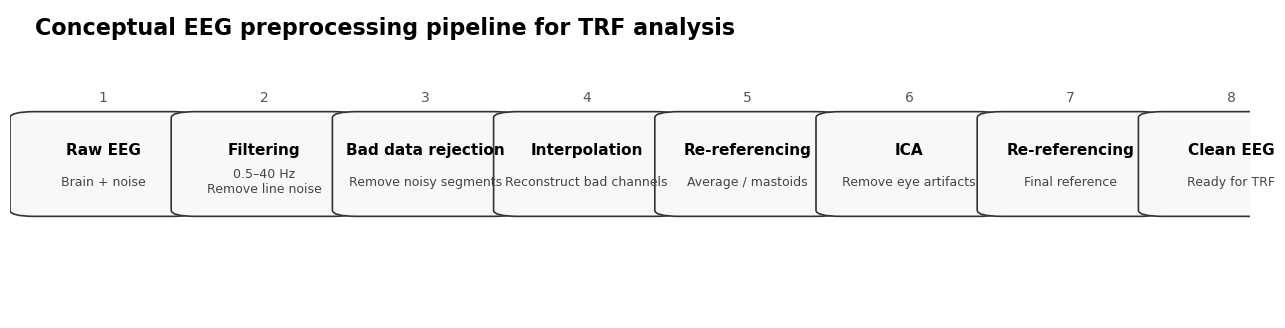

In [4]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

# ------------------------------------------------
# Helper functions
# ------------------------------------------------
def box(ax, x, y, w, h, title, subtitle=None):
    patch = FancyBboxPatch(
        (x, y), w, h,
        boxstyle="round,pad=0.02,rounding_size=0.02",
        linewidth=1.2,
        edgecolor="#333333",
        facecolor="#f8f8f8"
    )
    ax.add_patch(patch)

    ax.text(x + w/2, y + h*0.65, title,
            ha='center', va='center',
            fontsize=11, fontweight='bold')

    if subtitle:
        ax.text(x + w/2, y + h*0.30, subtitle,
                ha='center', va='center',
                fontsize=9, color="#444444")

def arrow(ax, x1, y1, x2, y2):
    ax.add_patch(FancyArrowPatch(
        (x1, y1), (x2, y2),
        arrowstyle='-|>',
        mutation_scale=12,
        linewidth=1.2,
        color="#333333"
    ))

# ------------------------------------------------
# Figure
# ------------------------------------------------
fig, ax = plt.subplots(figsize=(16, 4))
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis('off')

# Title
ax.text(0.02, 0.92,
        "Conceptual EEG preprocessing pipeline for TRF analysis",
        fontsize=16, fontweight='bold')

# ------------------------------------------------
# Layout
# ------------------------------------------------
y = 0.35
w = 0.11
h = 0.3

positions = [0.02, 0.15, 0.28, 0.41, 0.54, 0.67, 0.80, 0.93]

steps = [
    ("Raw EEG", "Brain + noise"),
    ("Filtering", "0.5–40 Hz\nRemove line noise"),
    ("Bad data rejection", "Remove noisy segments"),
    ("Interpolation", "Reconstruct bad channels"),
    ("Re-referencing", "Average / mastoids"),
    ("ICA", "Remove eye artifacts"),
    ("Re-referencing", "Final reference"),
    ("Clean EEG", "Ready for TRF")
]

# ------------------------------------------------
# Draw boxes
# ------------------------------------------------
for i, (title, subtitle) in enumerate(steps):
    x = positions[i]
    box(ax, x, y, w, h, title, subtitle)

    # arrows between boxes
    if i < len(steps) - 1:
        arrow(ax, x + w, y + h/2, positions[i+1], y + h/2)

# ------------------------------------------------
# Optional: step numbers (nice touch)
# ------------------------------------------------
for i, x in enumerate(positions):
    ax.text(x + w/2, y + h + 0.05, f"{i+1}",
            ha='center', fontsize=10, color="#555555")

# Save
plt.savefig("eeg_preprocessing_pipeline.png", dpi=300, bbox_inches='tight')
plt.show()
